In [ ]:
!ls /content/drive/MyDrive/P1/

In [ ]:
import pandas as pd

# Adjust the path to your dataset
path = '/content/drive/MyDrive/P1/dataset_olist/olist_order_reviews_dataset.csv'
df = pd.read_csv(path)

# Keep only review text & score
df = df[['review_comment_message', 'review_score']].dropna()
df.head()

,review_comment_message,review_score
3,Recebi bem antes do prazo estipulado.,5
4,Parabéns lojas lannister adorei comprar pela I...,5
9,aparelho eficiente. no site a marca do aparelh...,4
12,"Mas um pouco ,travando...pelo valor ta Boa.\r\n",4
15,"Vendedor confiável, produto ok e entrega antes...",5


In [ ]:
# Map 1–2 → Negative (0), 3 → Neutral (1), 4–5 → Positive (2)
def map_csat(score):
    if score in [1, 2]:
        return 0
    elif score == 3:
        return 1
    else:
        return 2

df['label'] = df['review_score'].apply(map_csat)

df['label'].value_counts()


,count
label,
2,26530
0,10890
1,3557


In [ ]:
from sklearn.model_selection import train_test_split

train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    df['review_comment_message'], df['label'], test_size=0.3, random_state=42, stratify=df['label'])

val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts, temp_labels, test_size=0.5, random_state=42, stratify=temp_labels)

print(len(train_texts), len(val_texts), len(test_texts))

28683 6147 6147


In [ ]:
from transformers import AutoTokenizer
from datasets import Dataset

MODEL = "nlptown/bert-base-multilingual-uncased-sentiment"
tokenizer = AutoTokenizer.from_pretrained(MODEL)

train_df = pd.DataFrame({'text': train_texts, 'label': train_labels})
val_df   = pd.DataFrame({'text': val_texts, 'label': val_labels})
test_df  = pd.DataFrame({'text': test_texts, 'label': test_labels})

train_dataset = Dataset.from_pandas(train_df)
val_dataset   = Dataset.from_pandas(val_df)
test_dataset  = Dataset.from_pandas(test_df)

def tokenize(batch):
    return tokenizer(batch['text'], padding=True, truncation=True, max_length=128)

train_dataset = train_dataset.map(tokenize, batched=True)
val_dataset   = val_dataset.map(tokenize, batched=True)
test_dataset  = test_dataset.map(tokenize, batched=True)

train_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])
val_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])
test_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Map:   0%|          | 0/28683 [00:00<?, ? examples/s]

Map:   0%|          | 0/6147 [00:00<?, ? examples/s]

Map:   0%|          | 0/6147 [00:00<?, ? examples/s]

In [ ]:
from transformers import AutoModelForSequenceClassification, Trainer, TrainingArguments


model = AutoModelForSequenceClassification.from_pretrained(
    MODEL,
    num_labels=3,
    ignore_mismatched_sizes=True
)

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    logging_dir='./logs',
    logging_steps=100,
    report_to="none"   # 🔑 disables W&B logging
)


from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import numpy as np

def compute_metrics(p):
    preds = np.argmax(p.predictions, axis=1)
    return {
        "accuracy": accuracy_score(p.label_ids, preds),
        "precision": precision_score(p.label_ids, preds, average="weighted"),
        "recall": recall_score(p.label_ids, preds, average="weighted"),
        "f1": f1_score(p.label_ids, preds, average="weighted"),
    }

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

trainer.train()


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at nlptown/bert-base-multilingual-uncased-sentiment and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([5]) in the checkpoint and torch.Size([3]) in the model instantiated
- classifier.weight: found shape torch.Size([5, 768]) in the checkpoint and torch.Size([3, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-2027195705.py:38: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.402200,0.394731,0.859281,0.817336,0.859281,0.826375
2,0.368100,0.419188,0.862860,0.838092,0.862860,0.841198
3,0.282000,0.430983,0.856027,0.842508,0.856027,0.848389


TrainOutput(global_step=5379, training_loss=0.35706248605178176, metrics={'train_runtime': 1981.1996, 'train_samples_per_second': 43.433, 'train_steps_per_second': 2.715, 'total_flos': 5570349499836576.0, 'train_loss': 0.35706248605178176, 'epoch': 3.0})

In [ ]:
from sklearn.metrics import classification_report

# Run predictions
preds = trainer.predict(test_dataset)

# Convert logits to predicted labels
import numpy as np
y_pred = np.argmax(preds.predictions, axis=1)
y_true = preds.label_ids

# Show classification metrics
print(classification_report(y_true, y_pred, digits=4))


              precision    recall  f1-score   support

           0     0.8039    0.8831    0.8416      1634
           1     0.4889    0.0413    0.0761       533
           2     0.8911    0.9643    0.9263      3980

    accuracy                         0.8627      6147
   macro avg     0.7280    0.6296    0.6147      6147
weighted avg     0.8330    0.8627    0.8301      6147



In [ ]:
output_dir = "/content/drive/MyDrive/P1/csat_3_model/"

trainer.save_model(output_dir)        # saves model, config, optimizer state
tokenizer.save_pretrained(output_dir) # saves tokenizer

print("✅ Model saved at:", output_dir)


In [ ]:
import pandas as pd

path = '/content/drive/MyDrive/P1/dataset_olist/olist_order_reviews_dataset.csv'
df = pd.read_csv(path)

df = df[['review_comment_message', 'review_score']].dropna()

# Map scores → labels
def map_csat(score):
    if score in [1, 2]:
        return 0
    elif score == 3:
        return 1
    else:
        return 2

df['label'] = df['review_score'].apply(map_csat)


In [ ]:
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer

train_texts, test_texts, train_labels, test_labels = train_test_split(
    df['review_comment_message'], df['label'], test_size=0.2, random_state=42, stratify=df['label']
)

tokenizer = AutoTokenizer.from_pretrained("nlptown/bert-base-multilingual-uncased-sentiment")

train_encodings = tokenizer(train_texts.tolist(), truncation=True, padding=True, max_length=128)
test_encodings = tokenizer(test_texts.tolist(), truncation=True, padding=True, max_length=128)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [ ]:
import torch

class CSATDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels.iloc[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = CSATDataset(train_encodings, train_labels)
test_dataset = CSATDataset(test_encodings, test_labels)


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

labels = np.array(train_labels)
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(labels), y=labels)
class_weights = torch.tensor(class_weights, dtype=torch.float)
print("✅ Class Weights:", class_weights)


✅ Class Weights: tensor([1.2542, 3.8408, 0.5148])


In [ ]:
from transformers import AutoModelForSequenceClassification

model_path = "/content/drive/MyDrive/P1/csat_3_model/"   # <-- your saved model folder
model = AutoModelForSequenceClassification.from_pretrained(
    model_path,
    num_labels=3
)


In [ ]:
from transformers import Trainer

class WeightedTrainer(Trainer):
    def __init__(self, class_weights=None, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        # Apply weighted cross-entropy loss
        import torch.nn as nn
        loss_fct = nn.CrossEntropyLoss(weight=self.class_weights.to(model.device))
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))

        return (loss, outputs) if return_outputs else loss


In [ ]:
from transformers import TrainingArguments
training_args = TrainingArguments(
    output_dir="./results_weighted",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_dir="./logs_weighted",
    report_to="none"
)


In [ ]:
trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    tokenizer=tokenizer,
    class_weights=class_weights
)


/tmp/ipython-input-2393483542.py:5: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `WeightedTrainer.__init__`. Use `processing_class` instead.
  super().__init__(*args, **kwargs)


In [ ]:
trainer.train()


Epoch,Training Loss,Validation Loss
1,0.600300,0.642978
2,0.530000,0.721692
3,0.466300,0.841828


TrainOutput(global_step=6147, training_loss=0.5375707814688409, metrics={'train_runtime': 2444.6339, 'train_samples_per_second': 40.228, 'train_steps_per_second': 2.514, 'total_flos': 6468840709906176.0, 'train_loss': 0.5375707814688409, 'epoch': 3.0})

In [ ]:
from sklearn.metrics import classification_report
import numpy as np

preds = trainer.predict(test_dataset)
y_pred = np.argmax(preds.predictions, axis=1)
y_true = preds.label_ids

print(classification_report(y_true, y_pred, digits=4))




              precision    recall  f1-score   support

           0     0.8222    0.8430    0.8325      2178
           1     0.2910    0.3666    0.3244       712
           2     0.9426    0.8999    0.9207      5306

    accuracy                         0.8385      8196
   macro avg     0.6852    0.7032    0.6925      8196
weighted avg     0.8540    0.8385    0.8455      8196



In [ ]:
output_dir = "/content/drive/MyDrive/P1/csat_weighted_model/"
trainer.save_model(output_dir)
tokenizer.save_pretrained(output_dir)
print("✅ Weighted model saved at:", output_dir)

✅ Weighted model saved at: /content/drive/MyDrive/P1/csat_weighted_model/


In [1]:
from sklearn.model_selection import train_test_split
import pandas as pd

path = '/content/drive/MyDrive/P1/dataset_olist/olist_order_reviews_dataset.csv'
df = pd.read_csv(path)
df = df[['review_comment_message', 'review_score']].dropna()

def map_csat(score):
    if score in [1, 2]:
        return 0
    elif score == 3:
        return 1
    else:
        return 2

df['label'] = df['review_score'].apply(map_csat)

_, test_texts, _, test_labels = train_test_split(
    df['review_comment_message'], df['label'], test_size=0.2, random_state=42, stratify=df['label']
)


In [2]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

MODEL_DIR = "/content/drive/MyDrive/P1/csat_weighted_model/"  # your saved model folder

tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_DIR)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(105879, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1

In [3]:
# Tokenize all test samples
encodings = tokenizer(
    test_texts.tolist(),
    truncation=True,
    padding=True,
    max_length=128,
    return_tensors='pt'
)


In [4]:
from torch.utils.data import DataLoader, TensorDataset
import numpy as np

# Prepare DataLoader
dataset = TensorDataset(encodings['input_ids'], encodings['attention_mask'], torch.tensor(test_labels.tolist()))
loader = DataLoader(dataset, batch_size=32)

all_preds, all_labels = [], []

with torch.no_grad():
    for batch in loader:
        input_ids, attention_mask, labels = [x.to(device) for x in batch]
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

y_true = np.array(all_labels)
y_pred = np.array(all_preds)


In [5]:
from sklearn.metrics import classification_report
print(classification_report(y_true, y_pred, digits=4, target_names=['Negative','Neutral','Positive']))


              precision    recall  f1-score   support

    Negative     0.8222    0.8430    0.8325      2178
     Neutral     0.2910    0.3666    0.3244       712
    Positive     0.9426    0.8999    0.9207      5306

    accuracy                         0.8385      8196
   macro avg     0.6852    0.7032    0.6925      8196
weighted avg     0.8540    0.8385    0.8455      8196



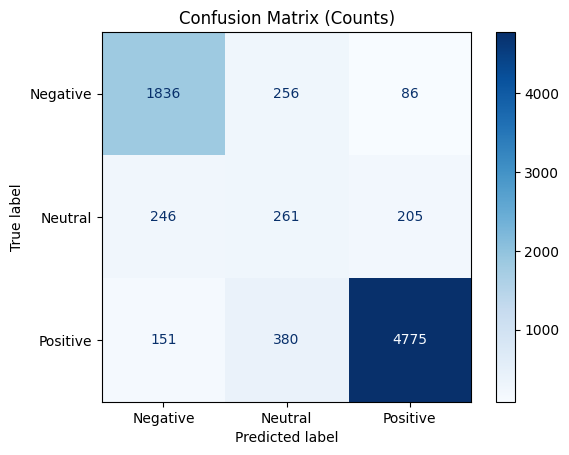

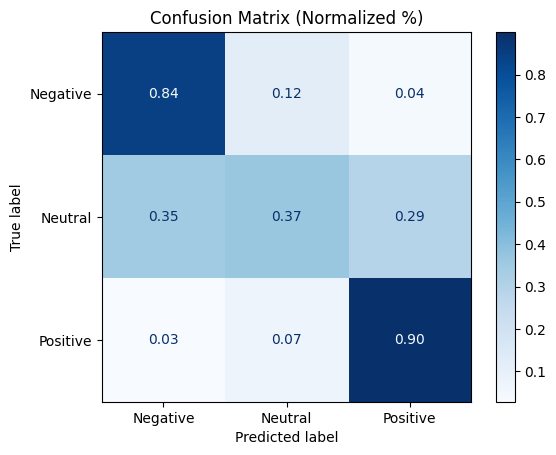

In [6]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix (counts)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Negative', 'Neutral', 'Positive']
)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix (Counts)")
plt.savefig("/content/drive/MyDrive/P1/confusion_matrix_counts.png", dpi=300, bbox_inches='tight')
plt.show()

# Plot confusion matrix (normalized)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm / cm.sum(axis=1, keepdims=True),
    display_labels=['Negative', 'Neutral', 'Positive']
)
disp.plot(cmap='Blues', values_format=".2f")
plt.title("Confusion Matrix (Normalized %)")
plt.savefig("/content/drive/MyDrive/P1/confusion_matrix_normalized.png", dpi=300, bbox_inches='tight')
plt.show()
